<a href="https://colab.research.google.com/github/a-elhaag/code-security-identifier/blob/main/dataset_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, re, ast, textwrap, difflib
from collections import Counter

!pip install -q datasets

PROJECT = "/content/drive/MyDrive/CSI_Project/datasets"
RAW     = f"{PROJECT}/raw"
os.makedirs(PROJECT, exist_ok=True)

print("ready")

Mounted at /content/drive
ready


In [2]:
from datasets import load_dataset

done = [f for f in os.listdir(PROJECT) if f.startswith("detectvul_")]

if len(done) >= 4:
    print(f"already downloaded ({len(done)} files), skipping")
else:
    for name in ["DetectVul/Vudenc", "DetectVul/CVEFixes"]:
        short = name.split("/")[1].lower()
        print(f"downloading {name}...")
        ds = load_dataset(name)
        for split in ds:
            path = f"{PROJECT}/detectvul_{short}_{split}.jsonl"
            with open(path, "w") as f:
                for row in ds[split]:
                    f.write(json.dumps(dict(row)) + "\n")
            print(f"  {split}: {len(ds[split])} samples")
    print("done")

already downloaded (4 files), skipping


In [3]:
STMT_TYPES = {
    ast.Import: "Import", ast.ImportFrom: "Import From",
    ast.Assign: "Assign", ast.AugAssign: "Augmented assign",
    ast.AnnAssign: "Assign", ast.Return: "Return",
    ast.If: "Condition", ast.For: "For/While", ast.While: "For/While",
    ast.With: "Expression", ast.Assert: "Assert", ast.Expr: "Expression",
    ast.FunctionDef: "Function declaration",
    ast.AsyncFunctionDef: "Function declaration",
    ast.ClassDef: "Expression", ast.Try: "Expression",
    ast.Raise: "Expression", ast.Pass: "Expression",
    ast.Break: "Expression", ast.Continue: "Expression",
}


def split_into_statements(code_str):
    """
    Takes a code string, returns (raw_lines, normalized_lines, types)
    or None if it can't be parsed.
    """
    if not code_str or not code_str.strip():
        return None

    # try parsing the code to get statement types
    line_types = {}
    try:
        tree = ast.parse(textwrap.dedent(code_str))
        for node in ast.walk(tree):
            if hasattr(node, "lineno") and isinstance(node, ast.stmt):
                line_types[node.lineno] = STMT_TYPES.get(type(node), "Expression")
    except SyntaxError:
        # try wrapping in a function
        try:
            wrapped = "def __w__():\n" + textwrap.indent(textwrap.dedent(code_str), "    ")
            tree = ast.parse(wrapped)
            for node in ast.walk(tree):
                if hasattr(node, "lineno") and isinstance(node, ast.stmt):
                    line_types[node.lineno - 1] = STMT_TYPES.get(type(node), "Expression")
        except SyntaxError:
            pass

    dedented = textwrap.dedent(code_str)
    all_lines = dedented.split("\n")

    raw, norm, types = [], [], []
    for i, line in enumerate(all_lines):
        if not line.strip():
            continue
        raw.append(line)
        norm.append(" ".join(line.split()))

        s = line.strip()
        if s.startswith('"""') or s.startswith("'''"):
            types.append("Docstring")
        else:
            types.append(line_types.get(i + 1, "Expression"))

    return (raw, norm, types) if raw else None


def label_vulnerable_lines(raw_lines, bad_texts):
    """
    Given statement lines and a list of known-bad text snippets,
    returns a list of 0/1 labels per line.
    """
    labels = [0] * len(raw_lines)
    if not bad_texts:
        return labels

    for i, line in enumerate(raw_lines):
        lc = line.strip()
        if not lc:
            continue
        for bt in bad_texts:
            bc = bt.strip()
            if not bc:
                continue
            if bc in lc or lc in bc or " ".join(bc.split()) == " ".join(lc.split()):
                labels[i] = 1
                break
    return labels


print("helpers loaded")

helpers loaded


In [4]:
CWE = {
    "command_injection": "CWE-077", "open_redirect": "CWE-601",
    "path_disclosure": "CWE-022", "remote_code_execution": "CWE-094",
    "sql": "CWE-089", "xsrf": "CWE-352", "xss": "CWE-079",
}

vudenc_out = []
skipped = 0

for vuln_name, cwe_id in CWE.items():
    path = f"{RAW}/plain_{vuln_name}"
    if not os.path.exists(path):
        print(f"  missing: plain_{vuln_name}")
        continue

    with open(path) as f:
        data = json.load(f)

    count = 0
    for repo, commits in data.items():
        for sha, info in commits.items():
            for fpath, fdata in info.get("files", {}).items():
                source = fdata.get("sourceWithComments", "") or fdata.get("source", "")
                changes = fdata.get("changes", [])

                bads = []
                for ch in changes:
                    if isinstance(ch, dict):
                        bads.extend(ch.get("badparts", []))

                if not source or not bads:
                    continue

                result = split_into_statements(source)
                if result is None:
                    skipped += 1
                    continue

                raw, norm, types = result
                labels = label_vulnerable_lines(raw, bads)

                if sum(labels) == 0:
                    skipped += 1
                    continue

                vudenc_out.append({
                    "lines": norm, "raw_lines": raw,
                    "label": labels, "type": types,
                    "cwe_id": cwe_id, "dataset_source": "local_vudenc",
                })
                count += 1

    print(f"  plain_{vuln_name} ({cwe_id}): {count} functions")

out = f"{PROJECT}/local_vudenc_converted.jsonl"
with open(out, "w") as f:
    for r in vudenc_out:
        f.write(json.dumps(r) + "\n")

stmts = sum(len(r["label"]) for r in vudenc_out)
vuln = sum(sum(r["label"]) for r in vudenc_out)
print(f"\ntotal: {len(vudenc_out)} functions, {stmts} statements ({vuln} vulnerable)")
print(f"skipped: {skipped}")

<unknown>:58: SyntaxWarning: invalid escape sequence '\.'
<unknown>:127: SyntaxWarning: invalid escape sequence '\,'
<unknown>:204: SyntaxWarning: invalid escape sequence '\,'
<unknown>:250: SyntaxWarning: invalid escape sequence '\*'
<unknown>:73: SyntaxWarning: invalid escape sequence '\d'
<unknown>:85: SyntaxWarning: invalid escape sequence '\d'
<unknown>:103: SyntaxWarning: invalid escape sequence '\d'
<unknown>:115: SyntaxWarning: invalid escape sequence '\d'
<unknown>:204: SyntaxWarning: invalid escape sequence '\('
<unknown>:229: SyntaxWarning: invalid escape sequence '\)'
<unknown>:418: SyntaxWarning: invalid escape sequence '\.'
<unknown>:450: SyntaxWarning: invalid escape sequence '\.'
<unknown>:327: SyntaxWarning: invalid escape sequence '\s'
<unknown>:129: SyntaxWarning: invalid escape sequence '\w'
<unknown>:130: SyntaxWarning: invalid escape sequence '\w'
<unknown>:129: SyntaxWarning: invalid escape sequence '\w'
<unknown>:130: SyntaxWarning: invalid escape sequence '\w'


  plain_command_injection (CWE-077): 197 functions


<unknown>:139: SyntaxWarning: invalid escape sequence '\('


  plain_open_redirect (CWE-601): 182 functions


<unknown>:86: SyntaxWarning: invalid escape sequence '\d'
<unknown>:179: SyntaxWarning: invalid escape sequence '\s'
<unknown>:181: SyntaxWarning: invalid escape sequence '\/'
<unknown>:189: SyntaxWarning: invalid escape sequence '\s'
<unknown>:191: SyntaxWarning: invalid escape sequence '\/'
<unknown>:180: SyntaxWarning: invalid escape sequence '\s'
<unknown>:182: SyntaxWarning: invalid escape sequence '\/'
<unknown>:190: SyntaxWarning: invalid escape sequence '\s'
<unknown>:192: SyntaxWarning: invalid escape sequence '\/'
<unknown>:47: SyntaxWarning: invalid escape sequence '\d'
<unknown>:213: SyntaxWarning: invalid escape sequence '\s'
<unknown>:37: SyntaxWarning: invalid escape sequence '\s'
<unknown>:52: SyntaxWarning: invalid escape sequence '\.'
<unknown>:55: SyntaxWarning: invalid escape sequence '\.'
<unknown>:105: SyntaxWarning: invalid escape sequence '\d'


...

  plain_sql (CWE-089): 656 functions


<unknown>:182: SyntaxWarning: invalid escape sequence '\d'
<unknown>:45: SyntaxWarning: invalid escape sequence '\/'
<unknown>:46: SyntaxWarning: invalid escape sequence '\/'
<unknown>:47: SyntaxWarning: invalid escape sequence '\/'
<unknown>:48: SyntaxWarning: invalid escape sequence '\/'
<unknown>:49: SyntaxWarning: invalid escape sequence '\/'
<unknown>:50: SyntaxWarning: invalid escape sequence '\/'
<unknown>:51: SyntaxWarning: invalid escape sequence '\/'
<unknown>:52: SyntaxWarning: invalid escape sequence '\/'
<unknown>:53: SyntaxWarning: invalid escape sequence '\/'
<unknown>:246: SyntaxWarning: invalid escape sequence '\;'
<unknown>:18: SyntaxWarning: invalid escape sequence '\s'
<unknown>:18: SyntaxWarning: invalid escape sequence '\s'
<unknown>:18: SyntaxWarning: invalid escape sequence '\s'
<unknown>:181: SyntaxWarning: invalid escape sequence '\s'
<unknown>:181: SyntaxWarning: invalid escape sequence '\s'
<unknown>:181: SyntaxWarning: invalid escape sequence '\s'
<unknown>

  plain_xsrf (CWE-352): 296 functions


<unknown>:9: SyntaxWarning: invalid escape sequence '\%'


  plain_xss (CWE-079): 81 functions

total: 1775 functions, 317495 statements (26154 vulnerable)
skipped: 1


In [5]:
func_out = []
skipped = 0

path = f"{RAW}/function_level_dataset.out"
if not os.path.exists(path):
    print("function_level_dataset.out not found in raw/")
else:
    with open(path) as f:
        records = [json.loads(l) for l in f]

    for rec in records:
        if rec.get("programming_language") != "Python":
            continue

        before = rec.get("code_before", "")
        after = rec.get("code_after", "")

        if not before.strip():
            continue

        result = split_into_statements(before)
        if result is None:
            skipped += 1
            continue

        raw, norm, types = result

        # figure out which lines changed by diffing before/after
        if after.strip():
            removed = set()
            for d in difflib.unified_diff(before.split("\n"), after.split("\n"), lineterm=""):
                if d.startswith("-") and not d.startswith("---"):
                    removed.add(d[1:].strip())

            labels = [0] * len(raw)
            for i, line in enumerate(raw):
                if line.strip() in removed:
                    labels[i] = 1
        else:
            labels = [1] * len(raw)

        gpt = rec.get("gpt_answer", "") + " " + rec.get("description", "")
        m = re.search(r"CWE-\d+", gpt)
        cwe_id = m.group(0) if m else "unknown"

        func_out.append({
            "lines": norm, "raw_lines": raw,
            "label": labels, "type": types,
            "cwe_id": cwe_id, "dataset_source": "local_funclevel",
        })

        # also add the safe version
        if after.strip():
            r2 = split_into_statements(after)
            if r2:
                raw2, norm2, types2 = r2
                func_out.append({
                    "lines": norm2, "raw_lines": raw2,
                    "label": [0] * len(raw2), "type": types2,
                    "cwe_id": cwe_id, "dataset_source": "local_funclevel",
                })

    out = f"{PROJECT}/local_funclevel_converted.jsonl"
    with open(out, "w") as f:
        for r in func_out:
            f.write(json.dumps(r) + "\n")

    v = sum(1 for r in func_out if sum(r["label"]) > 0)
    s = len(func_out) - v
    print(f"total: {len(func_out)} functions ({v} vulnerable, {s} safe)")
    print(f"skipped: {skipped}")

<unknown>:7: SyntaxWarning: invalid escape sequence '\s'
<unknown>:23: SyntaxWarning: invalid escape sequence '\!'
<unknown>:23: SyntaxWarning: invalid escape sequence '\!'
<unknown>:25: SyntaxWarning: invalid escape sequence '\s'


total: 3043 functions (1226 vulnerable, 1817 safe)
skipped: 0


In [6]:
sec_out = []

path = f"{RAW}/dataset.jsonl"
if not os.path.exists(path):
    print("dataset.jsonl not found in raw/")
else:
    with open(path) as f:
        for line in f:
            rec = json.loads(line)
            cwe_id = rec["ID"].split("_")[0]

            result = split_into_statements(rec["Insecure_code"])
            if result is None:
                continue

            raw, norm, types = result
            sec_out.append({
                "lines": norm, "raw_lines": raw,
                "label": [1] * len(raw), "type": types,
                "cwe_id": cwe_id, "dataset_source": "securityeval",
            })

    out = f"{PROJECT}/securityeval_eval.jsonl"
    with open(out, "w") as f:
        for r in sec_out:
            f.write(json.dumps(r) + "\n")

    print(f"total: {len(sec_out)} functions, {len(set(r['cwe_id'] for r in sec_out))} CWE types")

total: 121 functions, 69 CWE types


In [7]:
import random
random.seed(42)

train_all = []
test_all = []

# HuggingFace data
for fname in os.listdir(PROJECT):
    if not fname.startswith("detectvul_") or not fname.endswith(".jsonl"):
        continue
    is_test = "_test" in fname
    with open(f"{PROJECT}/{fname}") as f:
        for line in f:
            rec = json.loads(line)
            if "dataset_source" not in rec:
                rec["dataset_source"] = fname.split("_")[1]
            (test_all if is_test else train_all).append(rec)

# local converted data goes to training pool
for fname in ["local_vudenc_converted.jsonl", "local_funclevel_converted.jsonl"]:
    path = f"{PROJECT}/{fname}"
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                train_all.append(json.loads(line))

# shuffle and split off validation
random.shuffle(train_all)
val_size = max(1, len(train_all) // 10)
final_val = train_all[:val_size]
final_train = train_all[val_size:]

# save
for name, data in [("FINAL_train", final_train), ("FINAL_val", final_val), ("FINAL_test", test_all)]:
    path = f"{PROJECT}/{name}.jsonl"
    with open(path, "w") as f:
        for r in data:
            f.write(json.dumps(r) + "\n")

    n = len(data)
    stmts = sum(len(r["label"]) for r in data)
    vuln = sum(sum(r["label"]) for r in data)
    print(f"{name}: {n} functions, {stmts} statements ({vuln} vulnerable)")

print(f"\nsaved to {PROJECT}/")

FINAL_train: 19867 functions, 523331 statements (50950 vulnerable)
FINAL_val: 2207 functions, 60832 statements (6736 vulnerable)
FINAL_test: 4315 functions, 40874 statements (6255 vulnerable)

saved to /content/drive/MyDrive/CSI_Project/datasets/


In [8]:
print(f"{'file':<45} {'records':>8} {'size':>8}")
print("-" * 65)

for fname in sorted(os.listdir(PROJECT)):
    if not fname.endswith(".jsonl"):
        continue
    path = f"{PROJECT}/{fname}"
    size = os.path.getsize(path) / (1024 * 1024)
    with open(path) as f:
        count = sum(1 for _ in f)
    marker = " <<" if fname.startswith("FINAL") else ""
    print(f"{fname:<45} {count:>8,} {size:>7.1f}MB{marker}")

file                                           records     size
-----------------------------------------------------------------
FINAL_test.jsonl                                 4,315     4.8MB <<
FINAL_train.jsonl                               19,867    54.5MB <<
FINAL_val.jsonl                                  2,207     6.3MB <<
detectvul_cvefixes_test.jsonl                    1,146     1.3MB
detectvul_cvefixes_train.jsonl                   4,584     5.4MB
detectvul_vudenc_test.jsonl                      3,169     3.4MB
detectvul_vudenc_train.jsonl                    12,672    14.0MB
local_funclevel_converted.jsonl                  3,043     9.7MB
local_vudenc_converted.jsonl                     1,775    31.4MB
securityeval_eval.jsonl                            121     0.1MB


In [9]:
from google.colab import drive
drive.mount('/content/drive')

import json, os
from collections import Counter

D = "/content/drive/MyDrive/CSI_Project/datasets"

def load(name):
    with open(f"{D}/{name}") as f:
        return [json.loads(l) for l in f]

train = load("FINAL_train.jsonl")
val = load("FINAL_val.jsonl")
test = load("FINAL_test.jsonl")

print(f"train: {len(train)}  val: {len(val)}  test: {len(test)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train: 19867  val: 2207  test: 4315


In [10]:
for name, data in [("train", train), ("val", val), ("test", test)]:
    total = len(data)
    vuln = sum(1 for r in data if sum(r["label"]) > 0)
    safe = total - vuln
    pct = vuln / total * 100 if total else 0
    print(f"{name:>5}: {vuln} vulnerable / {safe} safe  ({pct:.1f}% vulnerable)")

train: 5009 vulnerable / 14858 safe  (25.2% vulnerable)
  val: 581 vulnerable / 1626 safe  (26.3% vulnerable)
 test: 647 vulnerable / 3668 safe  (15.0% vulnerable)


In [11]:
for name, data in [("train", train), ("val", val), ("test", test)]:
    total_s = sum(len(r["label"]) for r in data)
    vuln_s = sum(sum(r["label"]) for r in data)
    safe_s = total_s - vuln_s
    pct = vuln_s / total_s * 100 if total_s else 0
    print(f"{name:>5}: {vuln_s:,} vuln / {safe_s:,} safe stmts  ({pct:.1f}% vulnerable)")

train: 50,950 vuln / 472,381 safe stmts  (9.7% vulnerable)
  val: 6,736 vuln / 54,096 safe stmts  (11.1% vulnerable)
 test: 6,255 vuln / 34,619 safe stmts  (15.3% vulnerable)


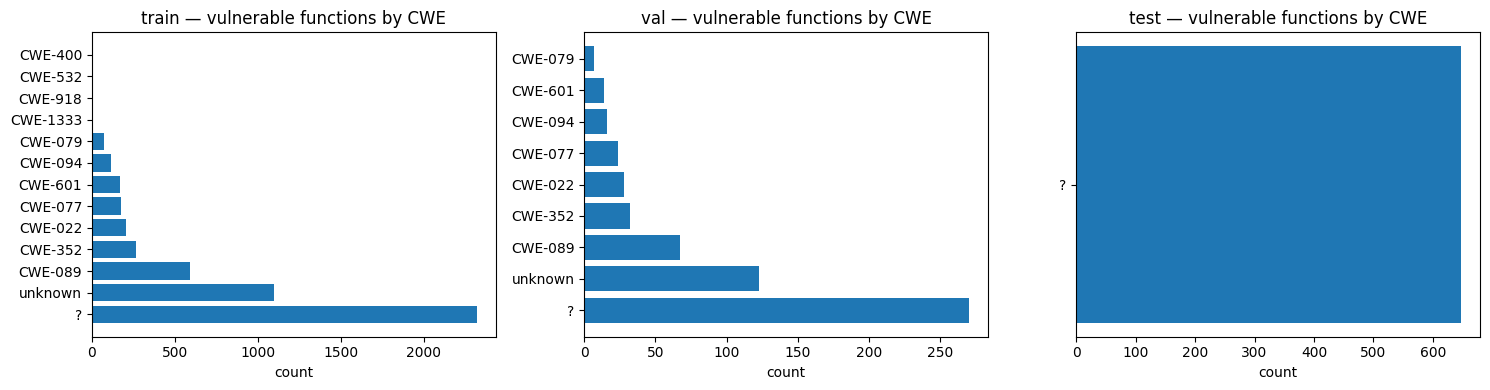

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, [("train", train), ("val", val), ("test", test)]):
    cwes = Counter(r.get("cwe_id", "?") for r in data if sum(r["label"]) > 0)
    if cwes:
        labels, counts = zip(*cwes.most_common())
        ax.barh(labels, counts)
        ax.set_title(f"{name} — vulnerable functions by CWE")
        ax.set_xlabel("count")

plt.tight_layout()
plt.show()

statements per function:
  min: 1  max: 771  avg: 26.3
  median: 7
  >50 stmts: 2076 (10.4%)
  >100 stmts: 1175 (5.9%)


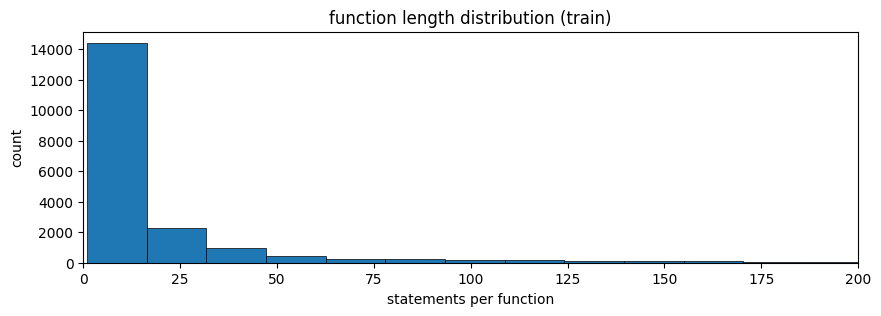

In [13]:
lengths = [len(r["label"]) for r in train]

print(f"statements per function:")
print(f"  min: {min(lengths)}  max: {max(lengths)}  avg: {sum(lengths)/len(lengths):.1f}")
print(f"  median: {sorted(lengths)[len(lengths)//2]}")

# how many are over 512 tokens (will get truncated)
over_50 = sum(1 for l in lengths if l > 50)
over_100 = sum(1 for l in lengths if l > 100)
print(f"  >50 stmts: {over_50} ({over_50/len(lengths)*100:.1f}%)")
print(f"  >100 stmts: {over_100} ({over_100/len(lengths)*100:.1f}%)")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.hist(lengths, bins=50, edgecolor="black", linewidth=0.5)
plt.xlabel("statements per function")
plt.ylabel("count")
plt.title("function length distribution (train)")
plt.xlim(0, 200)
plt.show()

vulnerable statements per vulnerable function:
  min: 1  max: 543  avg: 10.2
  median: 4


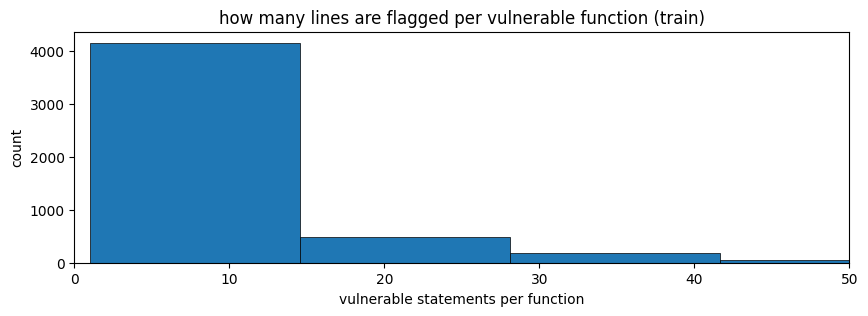

In [14]:
vuln_counts = [sum(r["label"]) for r in train if sum(r["label"]) > 0]

print(f"vulnerable statements per vulnerable function:")
print(f"  min: {min(vuln_counts)}  max: {max(vuln_counts)}  avg: {sum(vuln_counts)/len(vuln_counts):.1f}")
print(f"  median: {sorted(vuln_counts)[len(vuln_counts)//2]}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.hist(vuln_counts, bins=40, edgecolor="black", linewidth=0.5)
plt.xlabel("vulnerable statements per function")
plt.ylabel("count")
plt.title("how many lines are flagged per vulnerable function (train)")
plt.xlim(0, 50)
plt.show()

In [15]:
for name, data in [("train", train), ("val", val), ("test", test)]:
    sources = Counter(r.get("dataset_source", "?") for r in data)
    parts = ", ".join(f"{k}: {v}" for k, v in sources.most_common())
    print(f"{name:>5}: {parts}")

train: vudenc: 11397, cvefixes: 4145, local_funclevel: 2738, local_vudenc: 1587
  val: vudenc: 1275, cvefixes: 439, local_funclevel: 305, local_vudenc: 188
 test: vudenc: 3169, cvefixes: 1146


In [16]:
all_types = Counter()
vuln_types = Counter()

for r in train:
    for t, l in zip(r.get("type", []), r["label"]):
        all_types[t] += 1
        if l == 1:
            vuln_types[t] += 1

print(f"{'type':<25} {'total':>8} {'vuln':>8} {'vuln%':>8}")
print("-" * 53)
for t, total in all_types.most_common():
    v = vuln_types.get(t, 0)
    pct = v / total * 100 if total else 0
    print(f"{t:<25} {total:>8,} {v:>8,} {pct:>7.1f}%")

type                         total     vuln    vuln%
-----------------------------------------------------
Expression                 209,037   15,770     7.5%
Assign                      67,827    5,951     8.8%
Assign'                     53,155      288     0.5%
Condition                   48,465    1,609     3.3%
Expr'                       30,197      126     0.4%
Function declaration        18,194    1,006     5.5%
Docstring                   18,187    1,460     8.0%
Return                      16,469    1,209     7.3%
FunctionDef'                14,225        0     0.0%
Return'                     13,543       84     0.6%
Import From                  6,301      325     5.2%
ImportFrom'                  6,097       17     0.3%
For/While                    5,417      335     6.2%
For                          4,166       15     0.4%
Import                       3,659      117     3.2%
Import'                      3,018       10     0.3%
Augmented assign             1,870      193  

In [17]:
import random
random.seed(0)

# pick 3 vulnerable functions at random
vuln_samples = [r for r in train if sum(r["label"]) > 0]
picks = random.sample(vuln_samples, min(3, len(vuln_samples)))

for i, sample in enumerate(picks):
    cwe = sample.get("cwe_id", "?")
    src = sample.get("dataset_source", "?")
    print(f"--- sample {i+1} | {cwe} | from: {src} ---")

    lines = sample.get("raw_lines", sample.get("lines", []))
    labels = sample["label"]

    for j, (line, lbl) in enumerate(zip(lines[:20], labels[:20])):
        mark = ">>" if lbl == 1 else "  "
        print(f"  {mark} {j+1:>3} | {line[:80]}")

    if len(lines) > 20:
        print(f"       ... ({len(lines) - 20} more lines)")
    print()

--- sample 1 | ? | from: vudenc ---
       1 | def delete_event(self, event_id):...

       2 | sql = (
    """DELETE FROM events
                 WHERE event_id = {0}
        
       3 | affected_count = self.cur.execute(sql)

       4 | self.conn.commit()

       5 | return affected_count


--- sample 2 | ? | from: vudenc ---
       1 | """
Run Git commands in separate processes
"""

       2 | import shlex

       3 | import subprocess

       4 | from os import path

       5 | from typing import Dict

       6 | from .printing import print_green

       7 | from .printing import print_yellow

       8 | def shell(command: str) ->str:...

       9 | """docstring"""

      10 | cmd = shlex.split(command)

      11 | output_lines = subprocess.check_output(cmd).decode('utf-8').split('\n')

      12 | for index, line in enumerate(output_lines):

      13 | if '*' in line:

      14 | return '\n'.join(output_lines)

      15 | output_lines[index] = f'\x1b{line}\x1b'


--- sample 3 | CWE

In [18]:
issues = []

for split_name, data in [("train", train), ("val", val), ("test", test)]:
    for i, r in enumerate(data):
        # no statements
        if not r.get("label") or len(r["label"]) == 0:
            issues.append(f"{split_name}[{i}]: empty label list")

        # mismatched lengths
        n_labels = len(r.get("label", []))
        n_lines = len(r.get("lines", []))
        n_raw = len(r.get("raw_lines", []))
        n_types = len(r.get("type", []))

        if n_labels != n_lines and n_lines > 0:
            issues.append(f"{split_name}[{i}]: label({n_labels}) != lines({n_lines})")
        if n_labels != n_types and n_types > 0:
            issues.append(f"{split_name}[{i}]: label({n_labels}) != type({n_types})")

        # all vulnerable (suspicious for long functions)
        if n_labels > 10 and sum(r["label"]) == n_labels:
            issues.append(f"{split_name}[{i}]: all {n_labels} stmts marked vulnerable")

if issues:
    print(f"found {len(issues)} issues:")
    for iss in issues[:20]:
        print(f"  {iss}")
    if len(issues) > 20:
        print(f"  ... and {len(issues) - 20} more")
else:
    print("no issues found")

found 50 issues:
  train[18]: all 11 stmts marked vulnerable
  train[75]: all 33 stmts marked vulnerable
  train[789]: all 14 stmts marked vulnerable
  train[1599]: all 21 stmts marked vulnerable
  train[1920]: all 13 stmts marked vulnerable
  train[2883]: all 16 stmts marked vulnerable
  train[2888]: all 11 stmts marked vulnerable
  train[3205]: all 17 stmts marked vulnerable
  train[3863]: all 16 stmts marked vulnerable
  train[3915]: all 17 stmts marked vulnerable
  train[4825]: all 15 stmts marked vulnerable
  train[5844]: all 11 stmts marked vulnerable
  train[6103]: all 21 stmts marked vulnerable
  train[6122]: all 11 stmts marked vulnerable
  train[6876]: all 18 stmts marked vulnerable
  train[7613]: all 26 stmts marked vulnerable
  train[7743]: all 13 stmts marked vulnerable
  train[8410]: all 19 stmts marked vulnerable
  train[9146]: all 11 stmts marked vulnerable
  train[10277]: all 15 stmts marked vulnerable
  ... and 30 more


In [19]:
import plotly.graph_objects as go
from collections import Counter

# Prepare data
plot_data = {}
for name, data in [("Train", train), ("Val", val), ("Test", test)]:
    cwes = Counter(r.get("cwe_id", "?") for r in data if sum(r["label"]) > 0)
    if cwes:
        labels, counts = zip(*cwes.most_common(15)) # Top 15 for readability
        plot_data[name] = {"labels": labels, "counts": counts}

# Create figure
fig = go.Figure()

# Add traces for each split
for name, info in plot_data.items():
    fig.add_trace(
        go.Bar(
            x=info["counts"],
            y=info["labels"],
            name=name,
            orientation='h',
            visible=(name == "Train")
        )
    )

# Add dropdown menu
fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=list([
                dict(label="Train Split", method="update", args=[{"visible": [True, False, False]}, {"title": "Top CWEs in Training Set"}]),
                dict(label="Val Split", method="update", args=[{"visible": [False, True, False]}, {"title": "Top CWEs in Validation Set"}]),
                dict(label="Test Split", method="update", args=[{"visible": [False, False, True]}, {"title": "Top CWEs in Test Set"}]),
            ]),
            direction="down",
            showactive=True,
            x=0.1,
            y=1.15
        )
    ],
    title="Top CWEs in Training Set",
    xaxis_title="Number of Functions",
    yaxis_title="CWE ID",
    height=600,
    margin=dict(l=150)
)

fig.show()